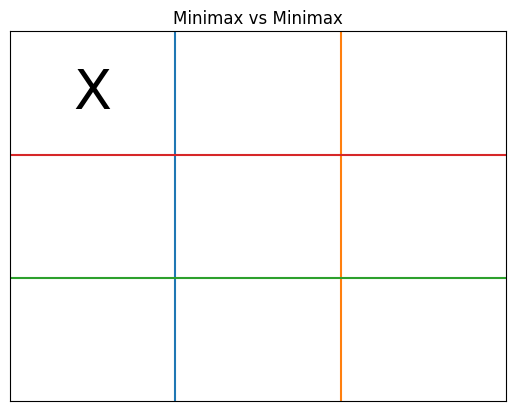

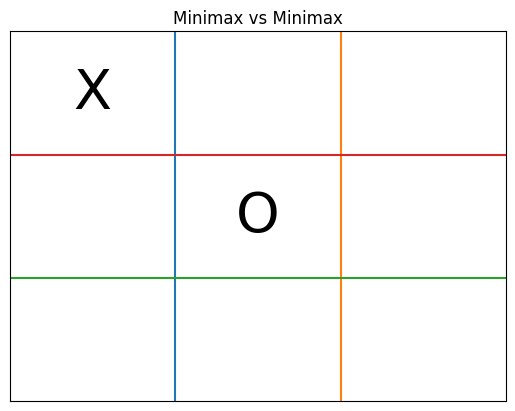

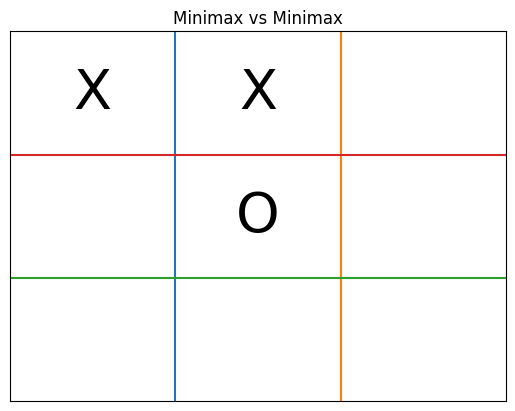

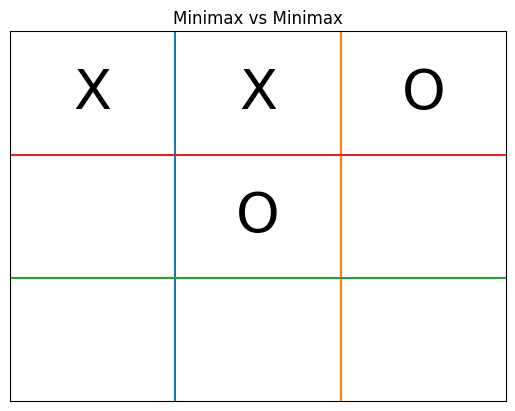

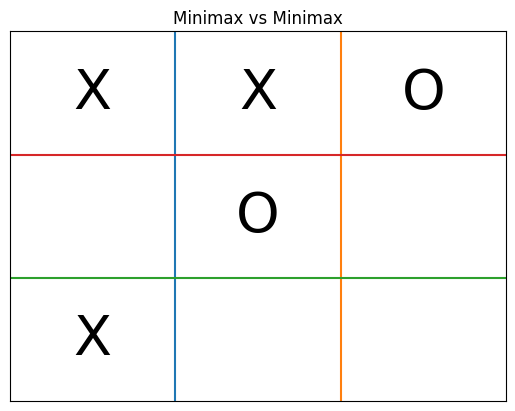

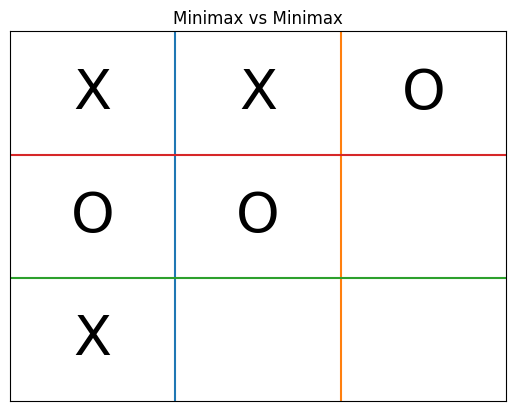

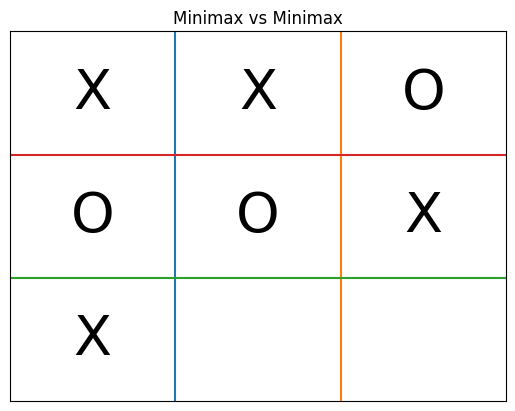

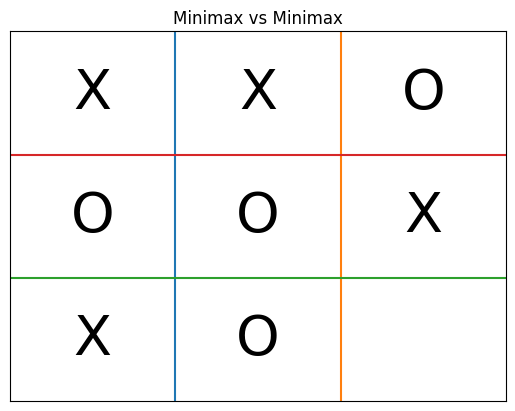

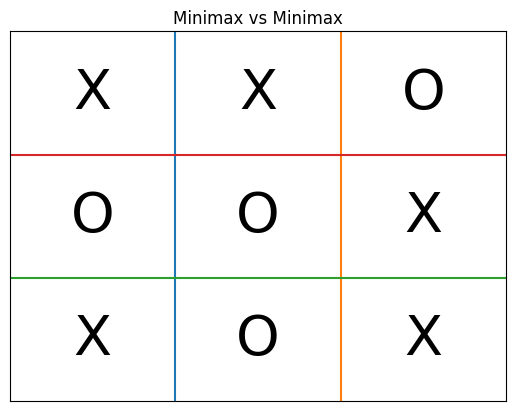

Game Draw!


In [1]:
import math
import matplotlib.pyplot as plt

board = [" "] * 9

def check_winner(board):
    combinations = [
        (0,1,2), (3,4,5), (6,7,8),
        (0,3,6), (1,4,7), (2,5,8),
        (0,4,8), (2,4,6)
    ]

    for a, b, c in combinations:
        if board[a] == board[b] == board[c] and board[a] != " ":
            return board[a]

    if " " not in board:
        return "Draw"

    return None


def minimax(board, maximizing):
    result = check_winner(board)

    if result == "O":
        return 1
    if result == "X":
        return -1
    if result == "Draw":
        return 0

    if maximizing:
        best = -math.inf

        for i in range(9):
            if board[i] == " ":
                board[i] = "O"
                score = minimax(board, False)
                board[i] = " "
                best = max(best, score)

        return best

    else:
        best = math.inf

        for i in range(9):
            if board[i] == " ":
                board[i] = "X"
                score = minimax(board, True)
                board[i] = " "
                best = min(best, score)

        return best


def best_move(board, player):
    best_score = -math.inf if player == "O" else math.inf
    move = None

    for i in range(9):
        if board[i] == " ":
            board[i] = player

            score = minimax(
                board,
                player == "X"
            )

            board[i] = " "

            if player == "O" and score > best_score:
                best_score = score
                move = i

            if player == "X" and score < best_score:
                best_score = score
                move = i

    return move


def draw_board(board):
    plt.clf()

    plt.plot([1,1], [0,3])
    plt.plot([2,2], [0,3])
    plt.plot([0,3], [1,1])
    plt.plot([0,3], [2,2])

    for i in range(9):
        row = i // 3
        col = i % 3

        x = col + 0.5
        y = 2.5 - row

        if board[i] != " ":
            plt.text(
                x, y,
                board[i],
                fontsize=40,
                ha="center",
                va="center"
            )

    plt.xlim(0,3)
    plt.ylim(0,3)
    plt.xticks([])
    plt.yticks([])
    plt.title("Minimax vs Minimax")
    plt.pause(1)


plt.ion()

player = "X"

while True:
    move = best_move(board, player)
    board[move] = player

    draw_board(board)

    result = check_winner(board)

    if result:
        break

    player = "O" if player == "X" else "X"

plt.ioff()

if result == "Draw":
    print("Game Draw!")
else:
    print("Winner:", result)

plt.show()